## Import common libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load your cleaned data file

In [2]:
grid_df = pd.read_csv("../data/upper_east_distance_grid.csv")

grid_df.head()

,lat,lon,distance_km
0,10.377591,-1.286077,5.556407
1,10.427591,-1.286077,6.020737
2,10.377591,-1.236077,5.677843
3,10.427591,-1.236077,5.907209
4,10.477591,-1.236077,0.879330


## Define access categories

We convert distance → risk levels.

In [3]:
def access_score(distance):
    if distance <= 5:
        return "good"
    elif distance <= 10:
        return "moderate"
    else:
        return "poor"

## Apply scoring

In [4]:
grid_df["access_level"] = grid_df["distance_km"].apply(access_score)

grid_df.head()

,lat,lon,distance_km,access_level
0,10.377591,-1.286077,5.556407,moderate
1,10.427591,-1.286077,6.020737,moderate
2,10.377591,-1.236077,5.677843,moderate
3,10.427591,-1.236077,5.907209,moderate
4,10.477591,-1.236077,0.879330,good


## Check distribution

In [5]:
grid_df["access_level"].value_counts()

access_level
poor        110
moderate     45
good         30
Name: count, dtype: int64

## Visualize categories (clearer than raw distances)

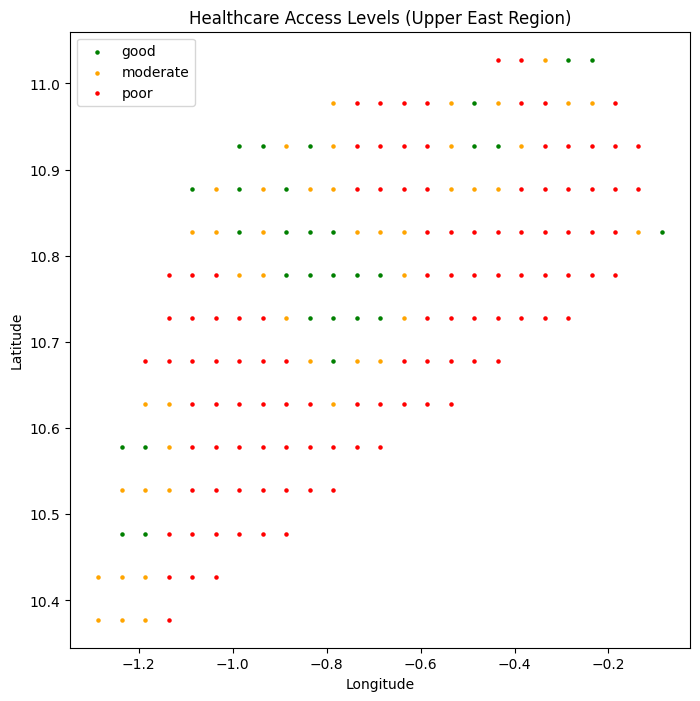

In [6]:
colors = {
    "good": "green",
    "moderate": "orange",
    "poor": "red"
}

plt.figure(figsize=(8,8))

for level, color in colors.items():
    subset = grid_df[grid_df["access_level"] == level]
    plt.scatter(subset["lon"], subset["lat"], c=color, label=level, s=5)

plt.legend()
plt.title("Healthcare Access Levels (Upper East Region)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Identify underserved areas

In [7]:
poor_areas = grid_df[grid_df["access_level"] == "poor"]

print(len(poor_areas))
poor_areas.head()

110


,lat,lon,distance_km,access_level
13,10.677591,-1.186077,11.687103,poor
14,10.377591,-1.136077,13.307535,poor
15,10.427591,-1.136077,11.674843,poor
16,10.477591,-1.136077,10.107607,poor
20,10.677591,-1.136077,13.203069,poor


## Simple recommendation logic

Let’s suggest locations for new clinics.

We’ll:

take worst points
suggest them as candidates

In [8]:
# Take top 20 worst (farthest distances)
top_candidates = grid_df.sort_values(by="distance_km", ascending=False).head(20)

top_candidates

,lat,lon,distance_km,access_level
53,10.477591,-0.936077,29.978399,poor
141,10.677591,-0.436077,29.115079,poor
63,10.477591,-0.886077,28.124043,poor
156,10.727591,-0.336077,27.634467,poor
163,10.727591,-0.286077,27.176970,poor
54,10.527591,-0.936077,25.871584,poor
164,10.777591,-0.286077,25.582617,poor
134,10.677591,-0.486077,25.291685,poor
149,10.727591,-0.386077,25.127655,poor
43,10.477591,-0.986077,24.938169,poor


A very simple but powerful idea:

“If we could build 20 new facilities, here’s where they should go.”

## Visualize recommendations

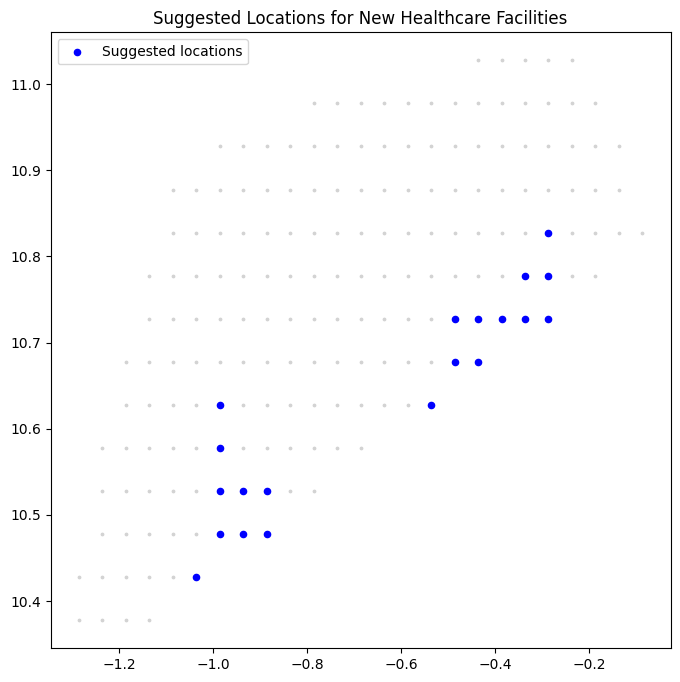

In [9]:
plt.figure(figsize=(8,8))

# plot all points lightly
plt.scatter(grid_df["lon"], grid_df["lat"], c="lightgrey", s=3)

# highlight recommendations
plt.scatter(top_candidates["lon"], top_candidates["lat"], c="blue", s=20, label="Suggested locations")

plt.legend()
plt.title("Suggested Locations for New Healthcare Facilities")

plt.show()

This scoring system is based solely on geographic distance and does not account for population density, facility capacity, or road accessibility. Therefore, recommendations should be interpreted as preliminary and complemented with additional data.

## Save results

In [ ]:
grid_df.to_csv("../data/upper_east_access_scores.csv", index=False)

: 